# APPL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('AAPL_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,0,$aapl un-stoppable!
1,0,"$aapl trading flat, then closing over yesterda..."
2,1,$aapl $spy $nflx $amzn $googl happy new year e...
3,1,$tsla $spy and $aapl were easy plays these pas...
4,0,$aapl sold my 290 calls for 70 percent profit ...


In [ ]:
dataset = load_data('AAPL_final.csv', columns=['body_clean', 'entities'])

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [3]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [4]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8546


In [6]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
proba0 = proba[:, 0]  # P(class 0)
proba1 = proba[:, 1]  # P(class 1)

# --- B) pick threshold that maximizes F1 for class 0 ---
ts_f1 = np.linspace(0.05, 0.95, 181)

best_f1_0 = None
for t in ts_f1:
    y_pred_t = np.where(proba0 >= t, 0, 1)  # predict 0 if P(class0) high enough
    f1_0 = f1_score(y_val, y_pred_t, pos_label=0)
    if best_f1_0 is None or f1_0 > best_f1_0["f1_0"]:
        best_f1_0 = {"f1_0": f1_0, "t": t, "pred": y_pred_t}

print("best F1 for class 0:", best_f1_0["f1_0"], "threshold on P(class0):", best_f1_0["t"])
print("bacc:", balanced_accuracy_score(y_val, best_f1_0["pred"]))
print(confusion_matrix(y_val, best_f1_0["pred"], labels=[0, 1]))
print(classification_report(y_val, best_f1_0["pred"], digits=4))

best F1 for class 0: 0.6765085474923581 threshold on P(class0): 0.32999999999999996
bacc: 0.7914895268462641
[[14939  6571]
 [ 7716 61464]]
              precision    recall  f1-score   support

           0     0.6594    0.6945    0.6765     21510
           1     0.9034    0.8885    0.8959     69180

    accuracy                         0.8425     90690
   macro avg     0.7814    0.7915    0.7862     90690
weighted avg     0.8455    0.8425    0.8438     90690



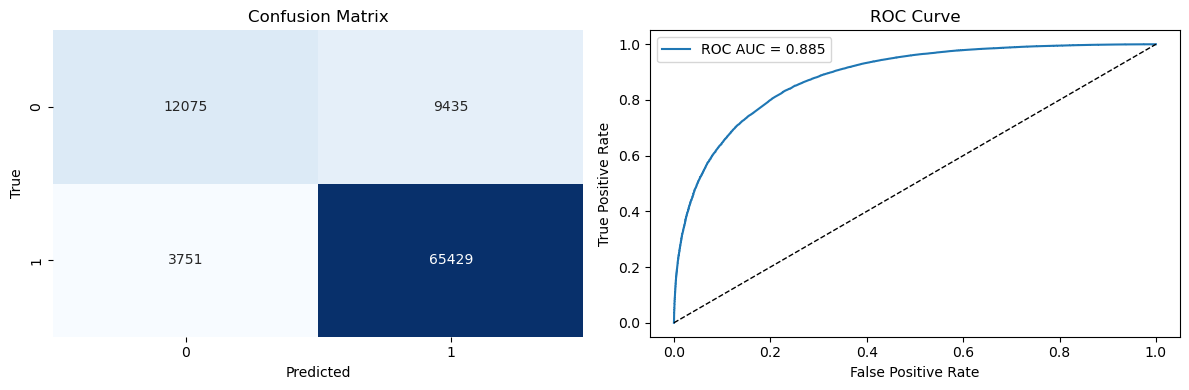

In [9]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# scikit-learn LogisticRegression does not return a Keras-like `history` object.
# Plot evaluation curves based on predictions instead.
y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# AMZN

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('AMZN_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,0,$amzn $fb $goog $aapl sounds like retail inves...
1,1,doj is not not going after $snap !!! look at r...
2,1,$amzn 800 shrs at $1888 if i get the stk “put ...
3,0,$googl $aapl $irbt $fb $amzn people do not und...
4,0,$amzn can this antitrust be released after ear...


In [ ]:
dataset = load_data('AMZN_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [12]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [13]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8676


In [14]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
proba0 = proba[:, 0]  # P(class 0)
proba1 = proba[:, 1]  # P(class 1)

# --- B) pick threshold that maximizes F1 for class 0 ---
ts_f1 = np.linspace(0.05, 0.95, 181)

best_f1_0 = None
for t in ts_f1:
    y_pred_t = np.where(proba0 >= t, 0, 1)  # predict 0 if P(class0) high enough
    f1_0 = f1_score(y_val, y_pred_t, pos_label=0)
    if best_f1_0 is None or f1_0 > best_f1_0["f1_0"]:
        best_f1_0 = {"f1_0": f1_0, "t": t, "pred": y_pred_t}

print("best F1 for class 0:", best_f1_0["f1_0"], "threshold on P(class0):", best_f1_0["t"])
print("bacc:", balanced_accuracy_score(y_val, best_f1_0["pred"]))
print(confusion_matrix(y_val, best_f1_0["pred"], labels=[0, 1]))
print(classification_report(y_val, best_f1_0["pred"], digits=4))

best F1 for class 0: 0.6521876314682373 threshold on P(class0): 0.3499999999999999
bacc: 0.7789019911828161
[[ 6201  3466]
 [ 3148 34482]]
              precision    recall  f1-score   support

           0     0.6633    0.6415    0.6522      9667
           1     0.9087    0.9163    0.9125     37630

    accuracy                         0.8602     47297
   macro avg     0.7860    0.7789    0.7823     47297
weighted avg     0.8585    0.8602    0.8593     47297



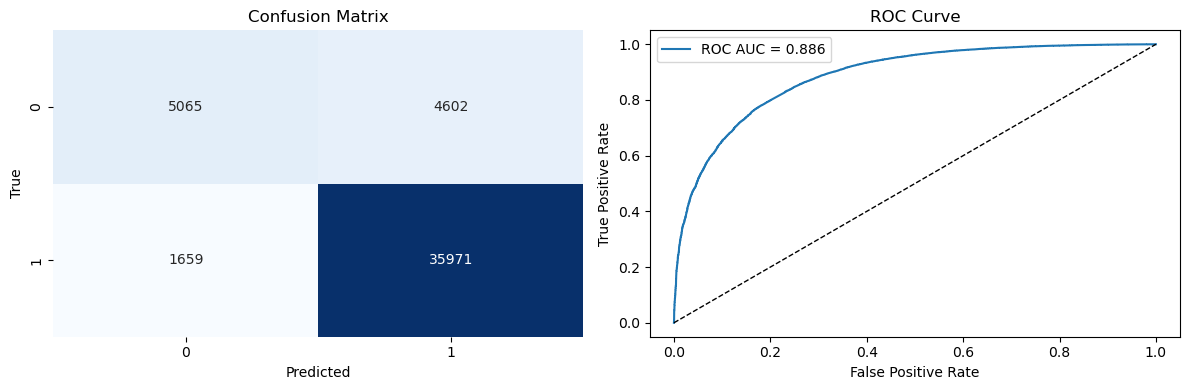

In [15]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# FB

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('FB_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,0,$fb $205 call buyers
1,0,$fb facebook - facebook q2 2019 earnings
2,0,$jd go look at the $fb move from 180 s to over...
3,0,$fb big money has puts in this for earnings an...
4,0,$fb do they report pre market or ah tomorrow?


In [ ]:
dataset = load_data('FB_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [18]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [19]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8336


In [20]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
proba0 = proba[:, 0]  # P(class 0)
proba1 = proba[:, 1]  # P(class 1)

# --- B) pick threshold that maximizes F1 for class 0 ---
ts_f1 = np.linspace(0.05, 0.95, 181)

best_f1_0 = None
for t in ts_f1:
    y_pred_t = np.where(proba0 >= t, 0, 1)  # predict 0 if P(class0) high enough
    f1_0 = f1_score(y_val, y_pred_t, pos_label=0)
    if best_f1_0 is None or f1_0 > best_f1_0["f1_0"]:
        best_f1_0 = {"f1_0": f1_0, "t": t, "pred": y_pred_t}

print("best F1 for class 0:", best_f1_0["f1_0"], "threshold on P(class0):", best_f1_0["t"])
print("bacc:", balanced_accuracy_score(y_val, best_f1_0["pred"]))
print(confusion_matrix(y_val, best_f1_0["pred"], labels=[0, 1]))
print(classification_report(y_val, best_f1_0["pred"], digits=4))

best F1 for class 0: 0.7140952380952381 threshold on P(class0): 0.31999999999999995
bacc: 0.8076206894263738
[[ 7498  1982]
 [ 4022 18871]]
              precision    recall  f1-score   support

           0     0.6509    0.7909    0.7141      9480
           1     0.9050    0.8243    0.8628     22893

    accuracy                         0.8145     32373
   macro avg     0.7779    0.8076    0.7884     32373
weighted avg     0.8305    0.8145    0.8192     32373



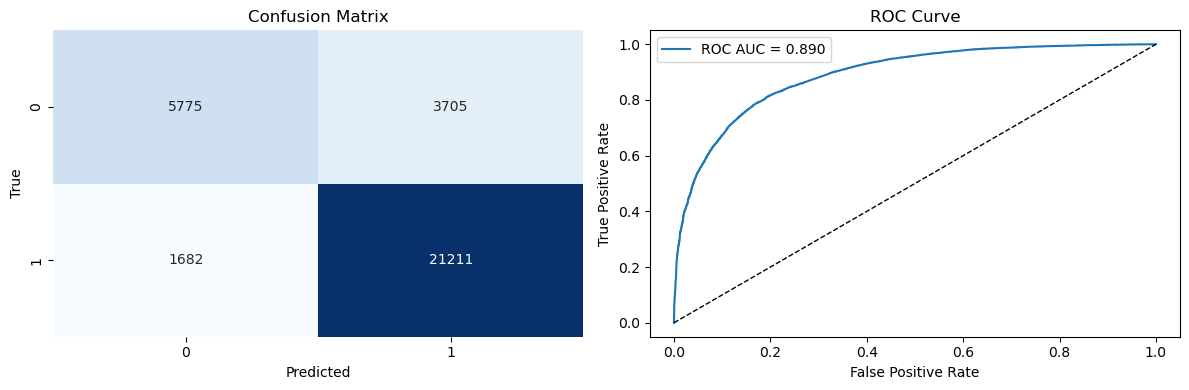

In [21]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# NVDA

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('NVDA_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,0,$nvda shorts using a lot of ammo trying to kee...
1,0,"$nvda quite a rebound today, i can hardly beli..."
2,1,as i said just over a week ago that $nvda woul...
3,1,$nvda shorting here is like picking up dimes i...
4,0,nvidia investing in â€ ̃once in a lifetime opp...


In [ ]:
dataset = load_data('NVDA_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [24]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [25]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8684


In [26]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
proba0 = proba[:, 0]  # P(class 0)
proba1 = proba[:, 1]  # P(class 1)

# --- B) pick threshold that maximizes F1 for class 0 ---
ts_f1 = np.linspace(0.05, 0.95, 181)

best_f1_0 = None
for t in ts_f1:
    y_pred_t = np.where(proba0 >= t, 0, 1)  # predict 0 if P(class0) high enough
    f1_0 = f1_score(y_val, y_pred_t, pos_label=0)
    if best_f1_0 is None or f1_0 > best_f1_0["f1_0"]:
        best_f1_0 = {"f1_0": f1_0, "t": t, "pred": y_pred_t}

print("best F1 for class 0:", best_f1_0["f1_0"], "threshold on P(class0):", best_f1_0["t"])
print("bacc:", balanced_accuracy_score(y_val, best_f1_0["pred"]))
print(confusion_matrix(y_val, best_f1_0["pred"], labels=[0, 1]))
print(classification_report(y_val, best_f1_0["pred"], digits=4))

best F1 for class 0: 0.6534877734877734 threshold on P(class0): 0.33999999999999997
bacc: 0.7784144912972586
[[ 6347  3590]
 [ 3141 35213]]
              precision    recall  f1-score   support

           0     0.6690    0.6387    0.6535      9937
           1     0.9075    0.9181    0.9128     38354

    accuracy                         0.8606     48291
   macro avg     0.7882    0.7784    0.7831     48291
weighted avg     0.8584    0.8606    0.8594     48291



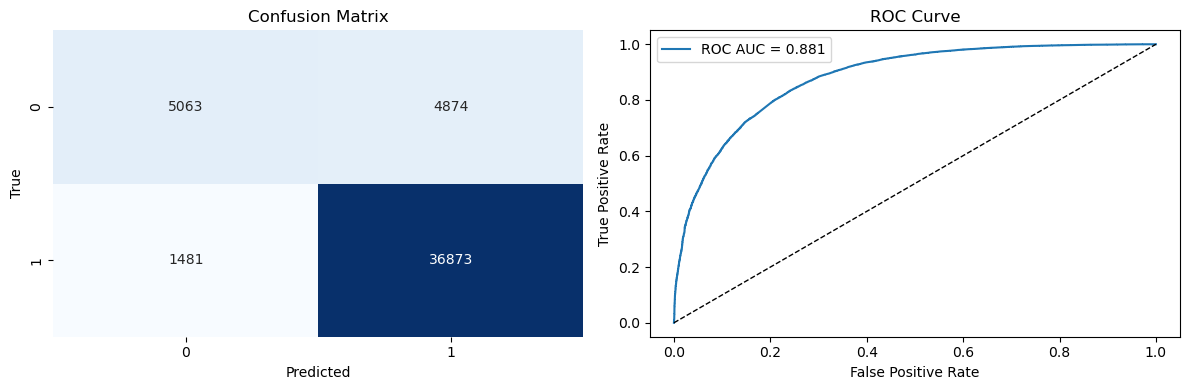

In [27]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# TSLA

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import datasets, metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Defer TensorFlow and CUDA setup to the training cells so the notebook kernel can connect faster.
path_to_data = '../pre-processing/'

def load_data(file_name, columns=None):
    if columns is None:
        return pd.read_csv(path_to_data + file_name)
    return pd.read_csv(path_to_data + file_name, usecols=columns)
load_data('TSLA_final.csv', columns=['body_clean', 'entities']).head()

,entities,body_clean
0,1,$tsla
1,-1,$tsla it so painful holding puts over xmas but...
2,1,$shak sorry morgan stanley your price targets ...
3,1,$tsla oh boy! going to rocket thursday! 450 by...
4,0,$spy $tsla why is tesla at 425?


In [32]:
dataset = load_data('TSLA_final.csv', columns=['body_clean', 'entities'])

# Clean inputs: make sure we don't feed NaN/non-strings to TF-IDF
dataset['entities'] = pd.to_numeric(dataset['entities'], errors='coerce')
dataset = dataset.dropna(subset=['entities', 'body_clean']).copy()
dataset['body_clean'] = dataset['body_clean'].astype(str)

# Drop rows with no explicit sentiment tag (entities == 0 means user didn't tag/neutral)
dataset = dataset[dataset['entities'] != 0].copy()

# Binary: -1 (bearish) -> 0, 1 (bullish) -> 1
y_all = (dataset['entities'].values == 1).astype(int)

X_train_text, X_val_text, y_train, y_val = train_test_split(
    dataset['body_clean'].values,
    y_all,
    test_size=0.2,
    random_state=2,
    stratify=y_all
)

features = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                             max_df=0.95, sublinear_tf=True, max_features=200_000)),
])

X_train = features.fit_transform(X_train_text)
X_val   = features.transform(X_val_text)

In [33]:
model = LogisticRegression(random_state=42, max_iter=2000, C=3.0, penalty='l2', solver='liblinear')
history = model.fit(X_train, y_train)

In [34]:
y_pred = model.predict(X_val)
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(y_val, y_pred)))

Model accuracy score: 0.8468


In [35]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report,
    balanced_accuracy_score, f1_score
)

proba = model.predict_proba(X_val)
proba0 = proba[:, 0]  # P(class 0)
proba1 = proba[:, 1]  # P(class 1)

# --- B) pick threshold that maximizes F1 for class 0 ---
ts_f1 = np.linspace(0.05, 0.95, 181)

best_f1_0 = None
for t in ts_f1:
    y_pred_t = np.where(proba0 >= t, 0, 1)  # predict 0 if P(class0) high enough
    f1_0 = f1_score(y_val, y_pred_t, pos_label=0)
    if best_f1_0 is None or f1_0 > best_f1_0["f1_0"]:
        best_f1_0 = {"f1_0": f1_0, "t": t, "pred": y_pred_t}

print("best F1 for class 0:", best_f1_0["f1_0"], "threshold on P(class0):", best_f1_0["t"])
print("bacc:", balanced_accuracy_score(y_val, best_f1_0["pred"]))
print(confusion_matrix(y_val, best_f1_0["pred"], labels=[0, 1]))
print(classification_report(y_val, best_f1_0["pred"], digits=4))

best F1 for class 0: 0.6889425803494433 threshold on P(class0): 0.3449999999999999
bacc: 0.7912896164999939
[[ 44340  19203]
 [ 20836 160007]]
              precision    recall  f1-score   support

           0     0.6803    0.6978    0.6889     63543
           1     0.8928    0.8848    0.8888    180843

    accuracy                         0.8362    244386
   macro avg     0.7866    0.7913    0.7889    244386
weighted avg     0.8376    0.8362    0.8368    244386



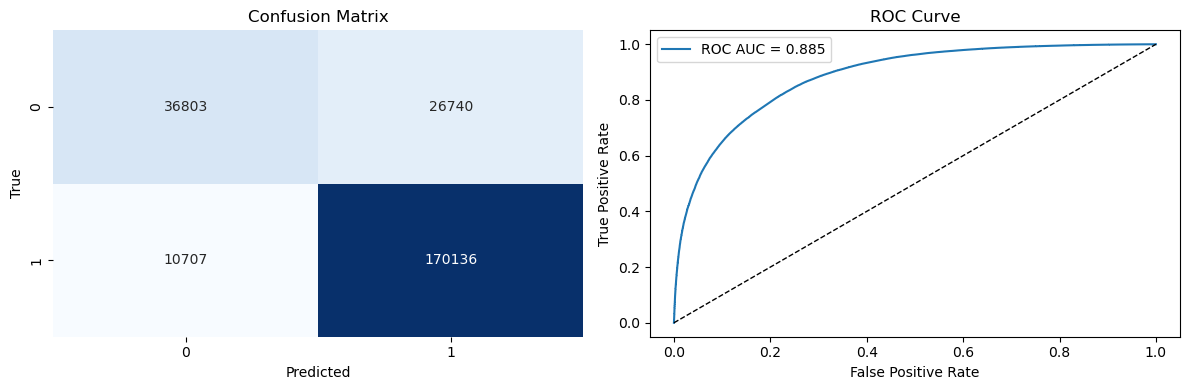

In [36]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_pred = model.predict(X_val)
proba1 = model.predict_proba(X_val)[:, 1]  # P(class 1)

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
fpr, tpr, _ = roc_curve(y_val, proba1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=[0, 1], yticklabels=[0, 1]
 )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()